# Life Expectancy Analysis

This notebook follows a standard data-science flow:

1. Load and reshape the World Bank life expectancy dataset
2. Perform exploratory data analysis (EDA)
3. Study Pakistan in comparison with the world, peer developing countries, and a highly developed benchmark
4. Identify the country with the strongest long-run improvement
5. Build a simple machine learning model to predict life expectancy

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load and reshape the data

The CSV file is in wide format, where each year is a separate column. We convert it into a long format because that is much easier for EDA, plotting, and machine learning.

In [2]:
data_path = Path("life expectancy at birth.csv")
wide_df = pd.read_csv(data_path)

year_cols = [col for col in wide_df.columns if col.isdigit()]

life_df = (
    wide_df
    .melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_cols,
        var_name="Year",
        value_name="LifeExpectancy",
    )
    .dropna(subset=["LifeExpectancy"])
)

life_df["Year"] = life_df["Year"].astype(int)
life_df["LifeExpectancy"] = life_df["LifeExpectancy"].astype(float)
life_df = life_df.sort_values(["Country Name", "Year"]).reset_index(drop=True)

life_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,LifeExpectancy
0,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,32.799
1,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,33.291
2,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1962,33.757
3,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1963,34.201
4,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1964,34.673


## 2. Quick dataset check

We first inspect the size, time coverage, missing values, and a few descriptive statistics.

In [3]:
summary = pd.Series({
    "rows": len(life_df),
    "countries_or_groups": life_df["Country Name"].nunique(),
    "years": f"{life_df['Year'].min()} - {life_df['Year'].max()}",
    "missing_values": int(life_df["LifeExpectancy"].isna().sum()),
})

display(summary.to_frame("value"))
display(life_df.describe(include="all").T[["count"]].head(8))

,value
rows,16926
countries_or_groups,265
years,1960 - 2023
missing_values,0


,count
Country Name,16926
Country Code,16926
Indicator Name,16926
Indicator Code,16926
Year,16926.0
LifeExpectancy,16926.0


In [4]:
latest_year = life_df["Year"].max()
latest_snapshot = life_df.query("Year == @latest_year").copy()

latest_snapshot.nlargest(10, "LifeExpectancy")[["Country Name", "LifeExpectancy"]]

,Country Name,LifeExpectancy
10555,Monaco,86.372000
13115,San Marino,85.706000
6655,"Hong Kong SAR, China",85.247317
9083,Liechtenstein,84.841463
5439,French Polynesia,84.070000
15035,Switzerland,84.056098
7739,Japan,84.041220
447,Andorra,84.041000
14267,Spain,83.882927
7611,Italy,83.700000


## 3. Exploratory Data Analysis (EDA)

We start with the overall trend and the most recent distribution of life expectancy values.

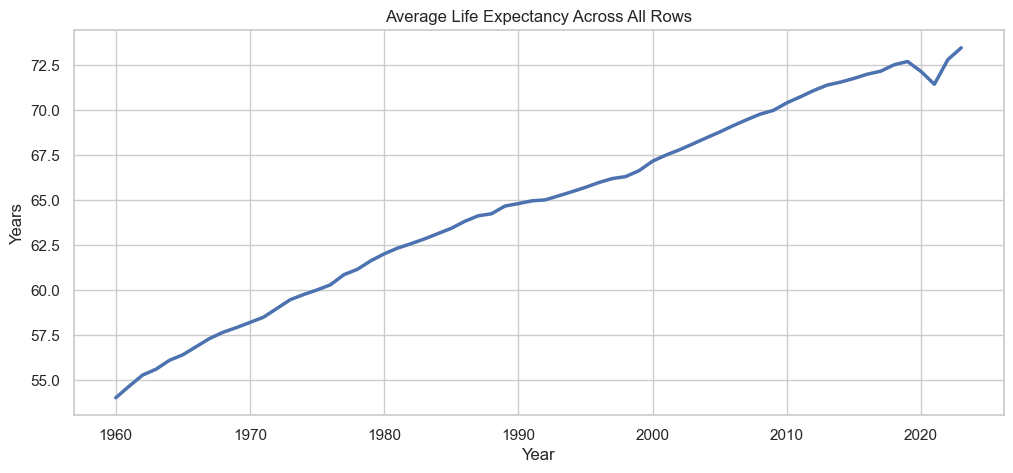

In [5]:
global_trend = life_df.groupby("Year", as_index=False)["LifeExpectancy"].mean()

fig, ax = plt.subplots()
sns.lineplot(data=global_trend, x="Year", y="LifeExpectancy", linewidth=2.5, ax=ax)
ax.set_title("Average Life Expectancy Across All Rows")
ax.set_ylabel("Years")
plt.show()

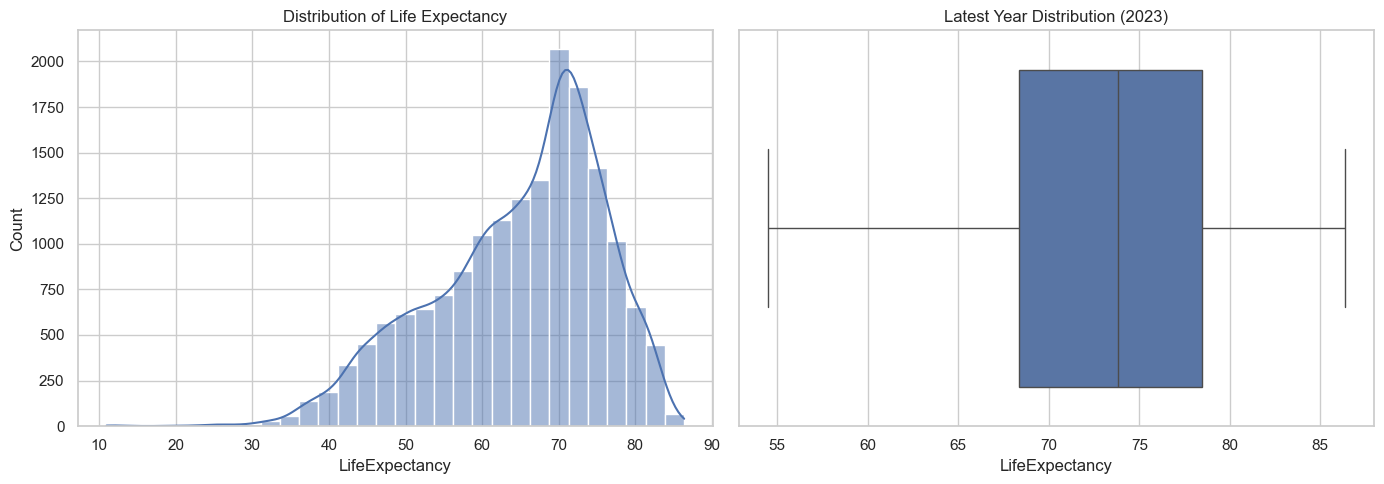

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(life_df["LifeExpectancy"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Life Expectancy")

sns.boxplot(data=latest_snapshot, x="LifeExpectancy", ax=axes[1])
axes[1].set_title(f"Latest Year Distribution ({latest_year})")

plt.tight_layout()
plt.show()

In [7]:
aggregate_words = [
    "World", "income", "IDA", "IBRD", "OECD", "demographic", "small states",
    "Fragile", "conflict", "Euro area", "European Union", "Arab World",
    "North America", "South Asia", "Sub-Saharan Africa", "Middle East",
    "Latin America", "Caribbean", "East Asia", "Europe & Central Asia",
    "Africa Eastern", "Africa Western", "Least developed", "Heavily indebted"
]

pattern = "|".join(re.escape(word) for word in aggregate_words)
country_df = life_df.loc[~life_df["Country Name"].str.contains(pattern, case=False, na=False)].copy()

country_latest = country_df.query("Year == @latest_year")
country_latest.nlargest(10, "LifeExpectancy")[["Country Name", "LifeExpectancy"]].reset_index(drop=True)

,Country Name,LifeExpectancy
0,Monaco,86.372000
1,San Marino,85.706000
2,"Hong Kong SAR, China",85.247317
3,Liechtenstein,84.841463
4,French Polynesia,84.070000
5,Switzerland,84.056098
6,Japan,84.041220
7,Andorra,84.041000
8,Spain,83.882927
9,Italy,83.700000


## 4. Pakistan compared with the world and other countries

This section answers the main analysis question:

- How has Pakistan changed over time?
- How does Pakistan compare with the world average?
- How does it compare with peer developing countries?
- How far is it from a highly developed benchmark?

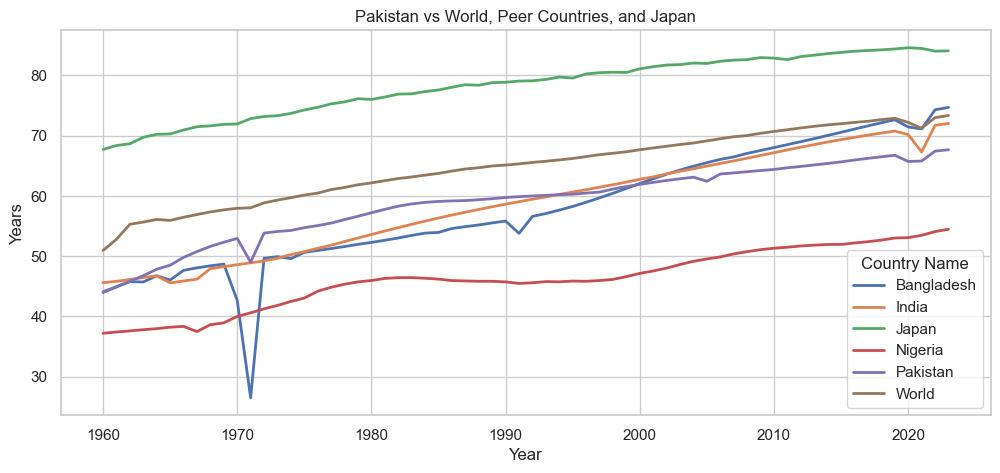

In [8]:
focus = ["Pakistan", "World", "India", "Bangladesh", "Nigeria", "Japan"]
focus_df = life_df[life_df["Country Name"].isin(focus)].copy()

fig, ax = plt.subplots()
sns.lineplot(data=focus_df, x="Year", y="LifeExpectancy", hue="Country Name", linewidth=2, ax=ax)
ax.set_title("Pakistan vs World, Peer Countries, and Japan")
ax.set_ylabel("Years")
plt.show()

In [9]:
selected_years = [1960, 1980, 2000, latest_year]
comparison_table = (
    focus_df[focus_df["Year"].isin(selected_years)]
    .pivot(index="Country Name", columns="Year", values="LifeExpectancy")
    .round(2)
    .sort_index()
)

comparison_table

Year,1960,1980,2000,2023
Country Name,,,,
Bangladesh,43.98,52.28,62.05,74.67
India,45.61,53.59,62.75,72.00
Japan,67.70,75.99,81.08,84.04
Nigeria,37.21,45.96,47.14,54.46
Pakistan,44.10,57.20,61.90,67.65
World,50.94,62.15,67.65,73.33


In [10]:
pakistan_df = life_df[life_df["Country Name"].eq("Pakistan")].copy()
world_df = life_df[life_df["Country Name"].eq("World")].copy()

pakistan_gap = (
    pakistan_df[["Year", "LifeExpectancy"]]
    .merge(world_df[["Year", "LifeExpectancy"]], on="Year", suffixes=("_Pakistan", "_World"))
)
pakistan_gap["Gap_vs_World"] = pakistan_gap["LifeExpectancy_Pakistan"] - pakistan_gap["LifeExpectancy_World"]

pakistan_gap.tail()

,Year,LifeExpectancy_Pakistan,LifeExpectancy_World,Gap_vs_World
59,2019,66.729,72.868657,-6.139657
60,2020,65.701,72.181979,-6.480979
61,2021,65.773,71.215219,-5.442219
62,2022,67.417,72.968290,-5.551290
63,2023,67.649,73.328950,-5.679950


## 5. Which country improved the most?

We measure long-run improvement as:

`latest available life expectancy - earliest available life expectancy`

To keep the comparison fair, we focus on country-like rows and require enough yearly observations.

In [11]:
improvement_df = (
    country_df.groupby("Country Name")
    .agg(
        first_year=("Year", "min"),
        last_year=("Year", "max"),
        first_value=("LifeExpectancy", "first"),
        last_value=("LifeExpectancy", "last"),
        observations=("LifeExpectancy", "size"),
    )
    .query("observations >= 40")
    .assign(improvement=lambda d: d["last_value"] - d["first_value"])
    .sort_values("improvement", ascending=False)
)

improvement_df.head(10)

,first_year,last_year,first_value,last_value,observations,improvement
Country Name,,,,,,
Oman,1960,2023,35.429,80.031,64,44.602
China,1960,2023,33.419,77.953,64,44.534
Maldives,1960,2023,38.244,81.041,64,42.797
Bhutan,1960,2023,36.367,72.975,64,36.608
"Yemen, Rep.",1960,2023,33.462,69.295,64,35.833
Algeria,1960,2023,40.839,76.261,64,35.422
Timor-Leste,1960,2023,32.402,67.689,64,35.287
"Iran, Islamic Rep.",1960,2023,43.297,77.654,64,34.357
Morocco,1960,2023,41.730,75.313,64,33.583


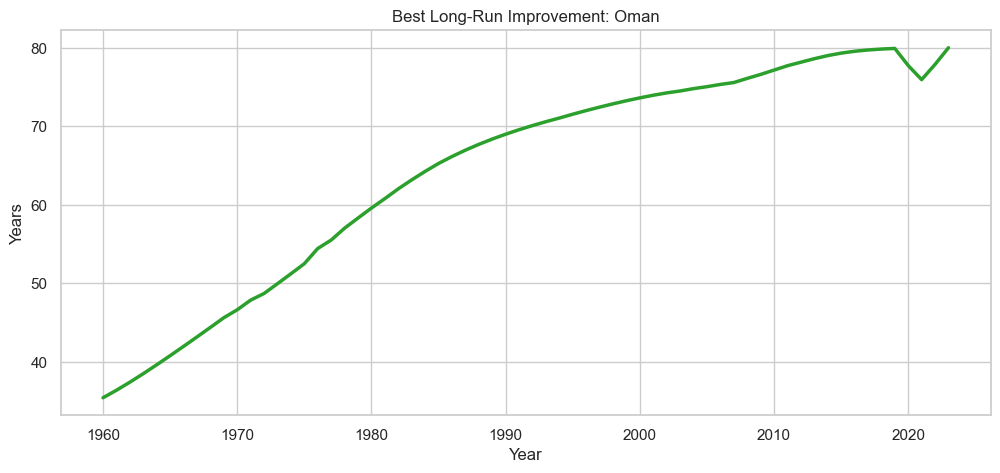

,first_value,last_value,improvement
Country Name,,,
Oman,35.429,80.031,44.602


In [12]:
best_country = improvement_df.index[0]
best_country_df = country_df[country_df["Country Name"].eq(best_country)].copy()

fig, ax = plt.subplots()
sns.lineplot(data=best_country_df, x="Year", y="LifeExpectancy", linewidth=2.5, color="tab:green", ax=ax)
ax.set_title(f"Best Long-Run Improvement: {best_country}")
ax.set_ylabel("Years")
plt.show()

improvement_df.head(1)[["first_value", "last_value", "improvement"]]

## 6. Machine learning model

We build a simple regression model that predicts life expectancy using:

- country name
- year
- previous 1-year life expectancy
- previous 5-year life expectancy

This is still a lightweight model, but it is much better than using only year and country.

In [13]:
ml_df = country_df.copy()
ml_df["lag_1"] = ml_df.groupby("Country Name")["LifeExpectancy"].shift(1)
ml_df["lag_5"] = ml_df.groupby("Country Name")["LifeExpectancy"].shift(5)
ml_df = ml_df.dropna(subset=["lag_1", "lag_5"]).copy()

train_df = ml_df[ml_df["Year"] < 2016]
test_df = ml_df[ml_df["Year"] >= 2016]

feature_cols = ["Country Name", "Year", "lag_1", "lag_5"]
target_col = "LifeExpectancy"

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("country", OneHotEncoder(handle_unknown="ignore"), ["Country Name"]),
        ("num", SimpleImputer(strategy="median"), ["Year", "lag_1", "lag_5"]),
    ]
)

model = Pipeline([
    ("prep", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=300, random_state=42)),
])

model.fit(X_train, y_train)
pred_test = model.predict(X_test)

metrics = pd.Series({
    "MAE": mean_absolute_error(y_test, pred_test),
    "R2": r2_score(y_test, pred_test),
})

metrics.to_frame("score")

,score
MAE,0.670307
R2,0.963132


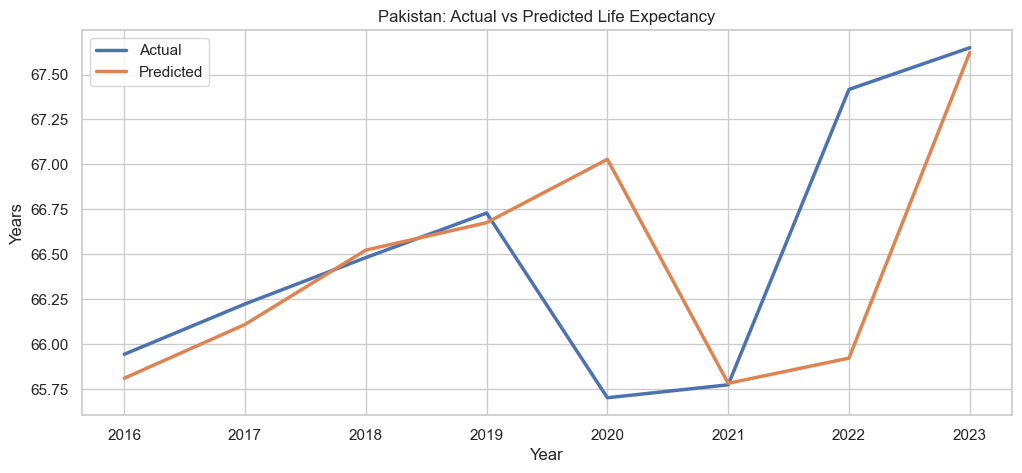

,Country Name,Year,LifeExpectancy,Prediction
12023,Pakistan,2019,66.729,66.675432
12024,Pakistan,2020,65.701,67.028069
12025,Pakistan,2021,65.773,65.781335
12026,Pakistan,2022,67.417,65.921441
12027,Pakistan,2023,67.649,67.621846


In [15]:
results_df = test_df[["Country Name", "Year", "LifeExpectancy"]].copy()
results_df["Prediction"] = pred_test

pakistan_pred = results_df[results_df["Country Name"].eq("Pakistan")]

fig, ax = plt.subplots()
sns.lineplot(data=pakistan_pred, x="Year", y="LifeExpectancy", label="Actual", linewidth=2.5, ax=ax)
sns.lineplot(data=pakistan_pred, x="Year", y="Prediction", label="Predicted", linewidth=2.5, ax=ax)
ax.set_title("Pakistan: Actual vs Predicted Life Expectancy")
ax.set_ylabel("Years")
plt.show()

pakistan_pred.tail()

## 7. Final observations

- Life expectancy generally improves over time, but the pace differs by country.
- Pakistan improves over the long run, but it still trails the world average and highly developed countries such as Japan.
- Pakistan can be compared more fairly with peer developing countries such as India, Bangladesh, and Nigeria.
- A simple machine learning model can already capture much of the trend when country identity and lagged history are included.

This notebook is intentionally compact, readable, and easy to extend with extra socioeconomic features later.